Crop Yield Analysis

In [1]:
import pandas as pd
import numpy as np
import janitor
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook

In [2]:
# df= load_workbook("../00_raw_data/crop yield data sheet.xlsx")
df = pd.read_excel("../00_raw_data/crop yield data sheet.xlsx")
df.head()

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,28,80.0,24.0,20.0,12.0
1,480.0,60.0,36,70.0,20.0,18.0,8.0
2,1250.0,75.0,29,78.0,22.0,19.0,11.0
3,450.0,65.0,35,70.0,19.0,18.0,9.0
4,1200.0,80.0,27,79.0,22.0,19.0,11.0


Data Preprocessing

In [3]:
# Rename column names
df.rename(
    columns={
        'Rain Fall (mm)': 'Rainfall_mm',
        'Temperatue': 'Temperature',
        'Yeild (Q/acre)': 'Yield_q/acre',
        'Nitrogen (N)': 'Nitrogen_n',
        'Phosphorus (P)': 'Phosphorus_p',
        'Potassium (K)': 'Potassium_k'
    },
    inplace=True
)


In [4]:
print(df.columns)

Index(['Rainfall_mm', 'Fertilizer', 'Temperature', 'Nitrogen_n',
       'Phosphorus_p', 'Potassium_k', 'Yield_q/acre'],
      dtype='object')


In [5]:
# Check for missing values
df.isnull().sum()

Rainfall_mm     10
Fertilizer      10
Temperature      9
Nitrogen_n      10
Phosphorus_p    10
Potassium_k     10
Yield_q/acre    10
dtype: int64

In [6]:
# Drop missing values
df = df.dropna()

# check for missing values 
df.isnull().sum()

Rainfall_mm     0
Fertilizer      0
Temperature     0
Nitrogen_n      0
Phosphorus_p    0
Potassium_k     0
Yield_q/acre    0
dtype: int64

In [7]:
# Check for duplicates
sum(df.duplicated())

4

In [8]:
# remove duplicates
df = df.drop_duplicates()

Descriptive Statistics

In [9]:
df.describe()

,Rainfall_mm,Fertilizer,Nitrogen_n,Phosphorus_p,Potassium_k,Yield_q/acre
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,841.263158,67.600000,70.610526,21.042105,18.031579,8.989474
std,398.808710,9.958852,6.574119,1.923626,1.818654,1.937836
min,400.000000,50.000000,59.000000,18.000000,15.000000,5.500000
25%,450.000000,60.000000,65.000000,19.000000,16.000000,7.000000
50%,1150.000000,70.000000,70.000000,21.000000,19.000000,9.000000
75%,1227.500000,77.000000,77.000000,23.000000,19.000000,11.000000
max,1300.000000,80.000000,80.000000,25.000000,22.000000,12.000000


Exploratory Data Analysis

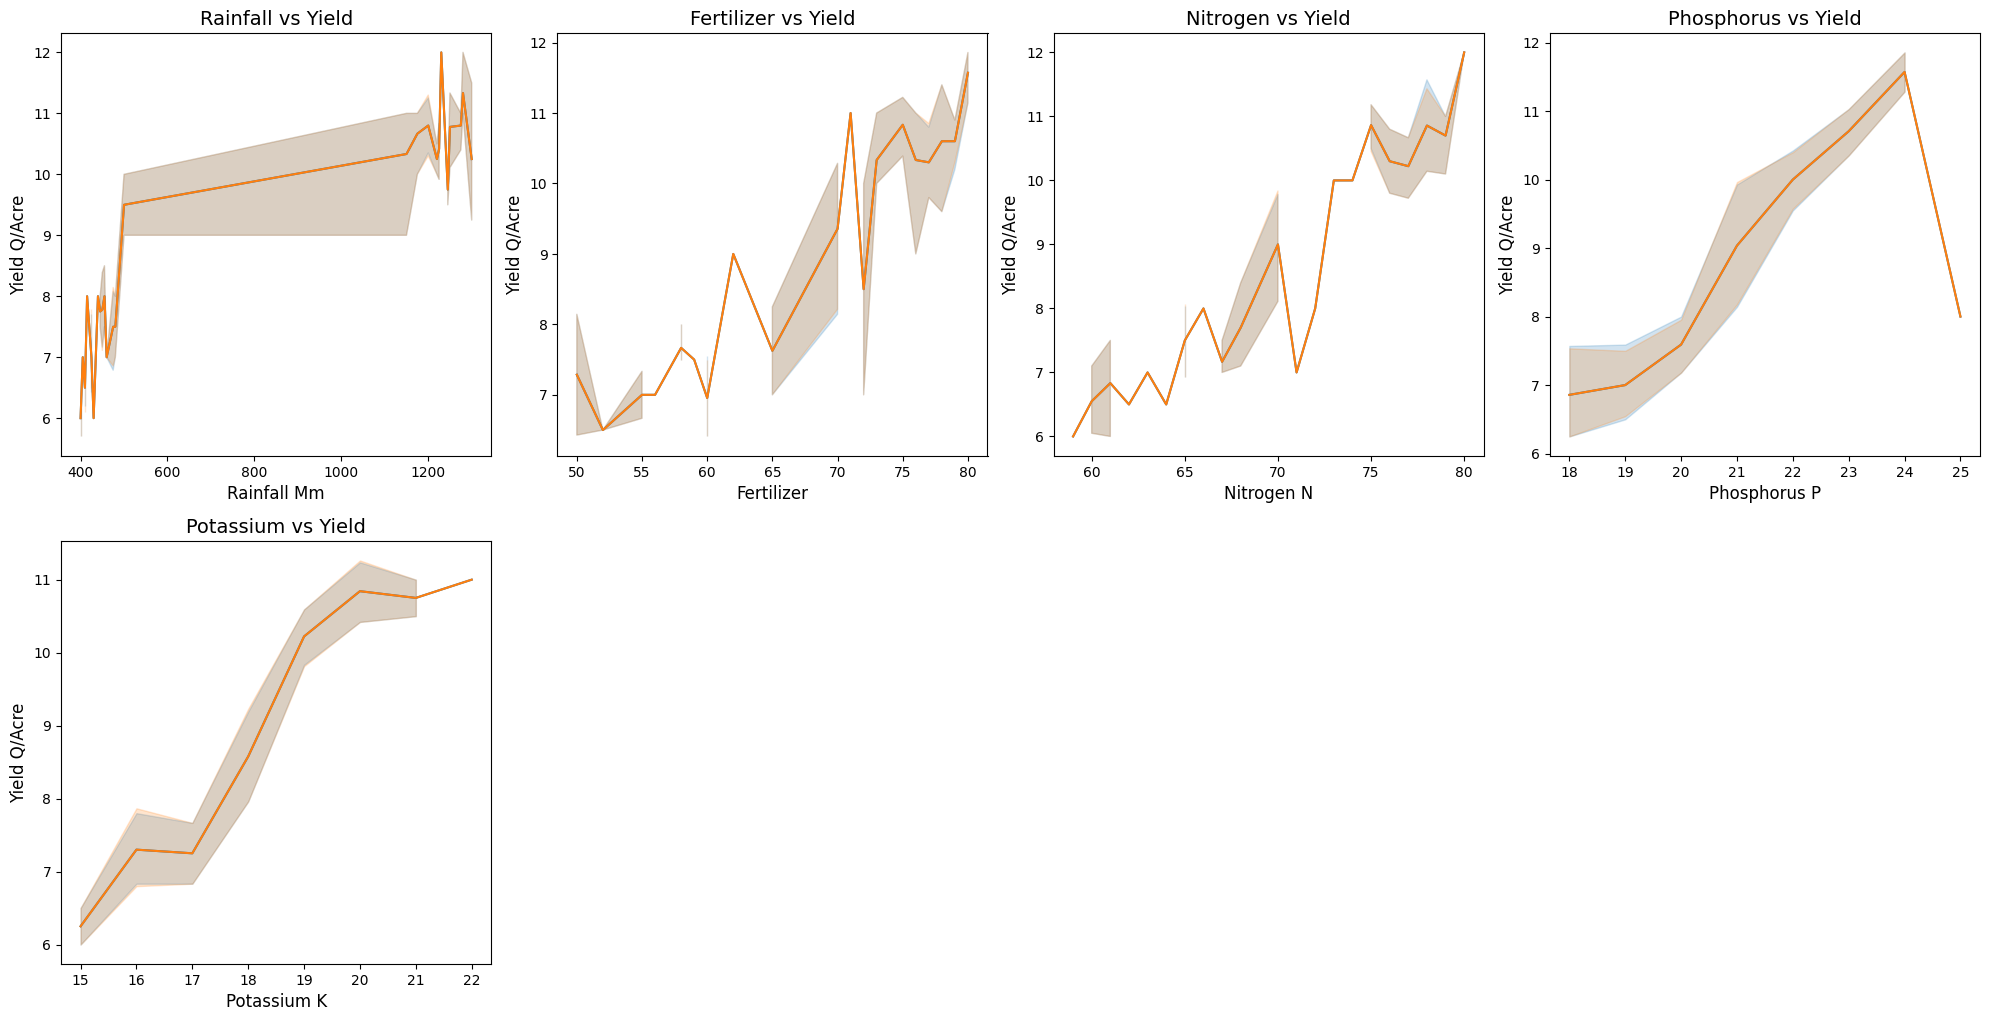

In [ ]:
fig, ax = plt.subplots(4,4, figsize = (20,20))
sns.lineplot(x='Rainfall_mm', y='Yield_q/acre', data=df, ax=ax[0,0])
sns.lineplot(x='Fertilizer', y='Yield_q/acre', data=df, ax=ax[0,1])
sns.lineplot(x='Nitrogen_n', y='Yield_q/acre', data=df, ax=ax[0,2])
sns.lineplot(x='Phosphorus_p', y='Yield_q/acre', data=df, ax=ax[0,3])
sns.lineplot(x='Potassium_k', y='Yield_q/acre', data=df,ax=ax[1,0])

# Titles and axis labels
plot_info = [
    ('Rainfall_mm', 'Yield_q/acre', ax[0, 0], 'Rainfall vs Yield'),
    ('Fertilizer', 'Yield_q/acre', ax[0, 1], 'Fertilizer vs Yield'),
    ('Nitrogen_n', 'Yield_q/acre', ax[0, 2], 'Nitrogen vs Yield'),
    ('Phosphorus_p', 'Yield_q/acre', ax[0, 3], 'Phosphorus vs Yield'),
    ('Potassium_k', 'Yield_q/acre', ax[1, 0], 'Potassium vs Yield')
]

# Plot and label each subplot
for x_col, y_col, axis, title in plot_info:
    sns.lineplot(x=x_col, y=y_col, data=df, ax=axis)
    axis.set_title(title, fontsize=14)
    axis.set_xlabel(x_col.replace('_', ' ').title(), fontsize=12)
    axis.set_ylabel(y_col.replace('_', ' ').title(), fontsize=12)


# Flatten the ax array for easy iteration
axes = ax.flatten()

# Number of plots used
num_used = 5

# Remove (turn off) unused axes
for i in range(num_used, len(axes)): 
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [37]:
# Export clean data
df.to_csv('../01_clean_data/cropyield.csv', index=False)